<a href="https://colab.research.google.com/github/jihyejung-400/public/blob/master/%ED%8C%8C%EC%9D%B4%EC%8D%AC%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%EA%B8%B0%EC%B4%88(2026)_%EB%85%B8%EC%A7%80%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%ED%95%B4%EB%B3%B4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 데이터 준비하기

In [ ]:
!unzip -q 'data_field.zip' -d '농촌진흥청_노지 현장 농가 데이터_20221231'
!unzip -q 'asos_weather.zip' -d 'asos_weather'

## 한글 표시 정상화 (그래프)

In [ ]:
!pip install -q koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 47.8 MB/s eta 0:00:00


## 데이터 불러오기

In [ ]:
import os
import pandas as pd
import glob

base_dir = './농촌진흥청_노지 현장 농가 데이터_20221231'

data = {
    '농가정보': {},
    '생육기본': {}
}
years = ['2019', '2020', '2021', '2022']

for year in years:
    year_dir = os.path.join(base_dir, year)

    # 농가정보 데이터 (XLSX)
    farm_info_dir = os.path.join(year_dir, '농가정보')
    if os.path.exists(farm_info_dir):
        farm_info_files = glob.glob(os.path.join(farm_info_dir, '*.xlsx'))
        for file in farm_info_files:
            filename = os.path.basename(file)
            crop_name = "농가정보"

            df = pd.read_excel(file, parse_dates=['정식일자', '수확일자'])
            df.columns = df.columns.str.strip()
            data[crop_name][f"{year}_{filename}"] = df

    # 생육기본 데이터 (XLSX)
    growth_dir = os.path.join(year_dir, '생육기본')
    if os.path.exists(growth_dir):
        growth_files = glob.glob(os.path.join(growth_dir, '*.xlsx'))
        for file in growth_files:
            filename = os.path.basename(file)
            parts = filename.split('_')

            crop_name = "생육기본"
            if len(parts) >= 3:
                crop_name = parts[2]
                if crop_name not in data:
                    data[crop_name] = {}

            df = pd.read_excel(file, parse_dates=['조사일'])
            df.columns = df.columns.str.strip()
            df['연도'] = year
            data[crop_name][f"{year}_{filename}"] = df


In [ ]:
display(data.keys())
display(data['농가정보'].keys())
display(data['밀'].keys())

dict_keys(['농가정보', '생육기본', '가을배추', '고추', '양파', '마늘', '고랭지배추', '콩', '밀'])

dict_keys(['2019_공개용_2019_농가정보.xlsx', '2020_공개용_2020_농가정보.xlsx', '2021_공개용_2021_농가정보.xlsx', '2022_공개용_2022_농가정보.xlsx'])

dict_keys(['2021_공개용_생육기본_밀_21년.xlsx', '2022_공개용_생육기본_밀_22년.xlsx'])

In [ ]:
display(data['농가정보']['2021_공개용_2021_농가정보.xlsx'].head())
display(data['밀']['2021_공개용_생육기본_밀_21년.xlsx'].head())

,연도,지역(도),시군,농가명,작목,품종,포장면적,주간거리,조간거리,파종일자,정식일자,수확일자,총수확량,비고
0,2021,경기도,여주시,1,가을배추,추광,5841.0,0.400,NaN,NaT,2021-08-12,2021-11-04,8302.174285,1열재배
1,2021,경기도,여주시,2,가을배추,추광,825.0,0.400,NaN,NaT,2021-08-10,2021-11-10,9253.333333,1열재배
2,2021,경기도,평택시,3,가을배추,추광,3300.0,0.400,0.29,NaT,2021-08-20,2021-10-29,5169.393939,NaN
3,2021,경기도,평택시,4,가을배추,CR명품,2640.0,0.420,0.27,NaT,2021-08-29,2021-10-29,8846.212121,NaN
4,2021,경기도,평택시,5,가을배추,불암3호,8250.0,0.408,0.44,NaT,2021-09-03,2021-11-09,8476.121212,농가에서 예정일(11/15이후)보다 조기 수확함


,영역,시도,시군구,품목,농가명,조사일,조사구역,개체번호,초장,수수,천립중,출수기,성숙기,비고,연도
0,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,1.0,19.0,NaN,NaN,NaT,NaT,NaN,2021
1,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,2.0,18.8,NaN,NaN,NaT,NaT,NaN,2021
2,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,3.0,19.3,NaN,NaN,NaT,NaT,NaN,2021
3,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,4.0,19.3,NaN,NaN,NaT,NaT,NaN,2021
4,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,5.0,15.8,NaN,NaN,NaT,NaT,NaN,2021


#### 작목별 농가정보 자료 병합

In [ ]:
farm_info = pd.concat(list(data['농가정보'].values()), ignore_index=True)
farm_info['시군'] = farm_info['시군'].str.strip()
farm_info.head()

,연도,지역(도),시군,농가명,작목,품종,포장면적,주간거리,조간거리,파종일자,정식일자,수확일자,총수확량,비고
0,2019,경기도,평택시,1,가을배추,추광,3305.0,0.25,0.30,NaT,2019-08-24,2019-10-28,NaN,NaN
1,2019,경기도,여주시,2,가을배추,추광,5950.0,0.37,NaN,NaT,2019-08-16,2019-10-28,NaN,1열재배
2,2019,경기도,여주시,3,가을배추,추광,990.0,0.37,NaN,NaT,2019-08-15,2019-10-28,NaN,1열재배
3,2019,경기도,평택시,4,가을배추,추광,7603.0,0.27,0.27,NaT,2019-08-20,2019-11-04,NaN,NaN
4,2019,경기도,평택시,5,가을배추,추광,3471.0,0.27,0.26,NaT,2019-08-25,2019-11-04,NaN,NaN


#### 작목별 생육기본 자료 병합

In [ ]:
import pandas as pd

crops = ['가을배추', '고랭지배추', '고추', '마늘', '밀', '양파', '콩']

crop_data = {}
for crop in crops:
    crop_data[crop] = pd.concat(list(data[crop].values()), ignore_index=True)

for crop in crops:
    display(crop_data[crop].head())

,영역,시도,시군구,품목,농가명,조사일,조사구역,개체번호,초장,엽수,구고,구폭,주중,비고,연도
0,생육기본,경기도,평택시,가을배추,1,2019-09-16,R1,1,22.1,14.0,NaN,NaN,NaN,NaN,2019
1,생육기본,경기도,평택시,가을배추,1,2019-09-16,R1,2,19.8,17.0,NaN,NaN,NaN,NaN,2019
2,생육기본,경기도,평택시,가을배추,1,2019-09-16,R1,3,21.3,17.0,NaN,NaN,NaN,NaN,2019
3,생육기본,경기도,평택시,가을배추,1,2019-09-16,R1,4,22.9,18.0,NaN,NaN,NaN,NaN,2019
4,생육기본,경기도,평택시,가을배추,1,2019-09-16,R1,5,23.5,18.0,NaN,NaN,NaN,NaN,2019


,영역,시도,시군구,품목,농가명,조사일,조사구역,개체번호,초장,엽수,구고,구폭,주중,비고,연도
0,생육기본,강원도,삼척시,고랭지배추,1,2019-07-29,R1,1,20.0,18.0,NaN,NaN,NaN,NaN,2019
1,생육기본,강원도,삼척시,고랭지배추,1,2019-07-29,R1,2,18.6,20.0,NaN,NaN,NaN,NaN,2019
2,생육기본,강원도,삼척시,고랭지배추,1,2019-07-29,R1,3,18.8,19.0,NaN,NaN,NaN,NaN,2019
3,생육기본,강원도,삼척시,고랭지배추,1,2019-07-29,R1,4,21.0,20.0,NaN,NaN,NaN,NaN,2019
4,생육기본,강원도,삼척시,고랭지배추,1,2019-07-29,R1,5,20.6,24.0,NaN,NaN,NaN,NaN,2019


,시도,시군구,품목,농가명,조사일,개체번호,초장,착과수,수확과수,비고,연도
0,경기도,안성시,고추,1,2019-06-14,1,71.4,7.0,NaN,NaN,2019
1,경기도,안성시,고추,1,2019-06-14,2,66.4,9.0,NaN,NaN,2019
2,경기도,안성시,고추,1,2019-06-14,3,64.2,8.0,NaN,NaN,2019
3,경기도,안성시,고추,1,2019-06-14,4,62.2,3.0,NaN,NaN,2019
4,경기도,안성시,고추,1,2019-06-14,5,65.2,5.0,NaN,NaN,2019


,영역,시도,시군구,품목,농가명,조사일,조사구역,개체번호,엽수,초장,구직경,생구무게,비고,연도
0,생육기본,충청북도,보은군,마늘,1,2019-03-14,R1,1,4.0,22.0,NaN,NaN,NaN,2019
1,생육기본,충청북도,보은군,마늘,1,2019-03-14,R1,2,5.0,18.0,NaN,NaN,NaN,2019
2,생육기본,충청북도,보은군,마늘,1,2019-03-14,R1,3,4.0,16.0,NaN,NaN,NaN,2019
3,생육기본,충청북도,보은군,마늘,1,2019-03-14,R1,4,4.0,12.6,NaN,NaN,NaN,2019
4,생육기본,충청북도,보은군,마늘,1,2019-03-14,R1,5,3.0,12.2,NaN,NaN,NaN,2019


,영역,시도,시군구,품목,농가명,조사일,조사구역,개체번호,초장,수수,천립중,출수기,성숙기,비고,연도
0,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,1.0,19.0,NaN,NaN,NaT,NaT,NaN,2021
1,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,2.0,18.8,NaN,NaN,NaT,NaT,NaN,2021
2,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,3.0,19.3,NaN,NaN,NaT,NaT,NaN,2021
3,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,4.0,19.3,NaN,NaN,NaT,NaT,NaN,2021
4,생육기본,전라북도,부안군,밀,1,2021-03-11,R1,5.0,15.8,NaN,NaN,NaT,NaT,NaN,2021


,영역,시도,시군구,품목,농가명,조사일,조사구역,개체번호,엽수,초장,구직경,생구무게,비고,연도
0,생육기본,전라남도,해남군,양파,1,2018-12-13,R1,1,2.0,15.0,NaN,NaN,NaN,2019
1,생육기본,전라남도,해남군,양파,1,2018-12-13,R1,2,2.0,14.0,NaN,NaN,NaN,2019
2,생육기본,전라남도,해남군,양파,1,2018-12-13,R1,3,2.0,19.0,NaN,NaN,NaN,2019
3,생육기본,전라남도,해남군,양파,1,2018-12-13,R1,4,2.0,18.0,NaN,NaN,NaN,2019
4,생육기본,전라남도,해남군,양파,1,2018-12-13,R1,5,2.0,11.0,NaN,NaN,NaN,2019


,영역,시도,시군구,품목,농가명,조사일,조사구역,개체번호,초장,주경마디수,분지마디수,분지수(가지수),종실중,100립중,개화기,착협기,종실비대기,성숙기,비고,연도
0,생육기본,강원도,영월군,콩,1,2021-07-19,R1,1.0,24.3,3.0,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaN,2021
1,생육기본,강원도,영월군,콩,1,2021-07-19,R1,2.0,18.7,1.0,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaN,2021
2,생육기본,강원도,영월군,콩,1,2021-07-19,R1,3.0,17.5,2.0,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaN,2021
3,생육기본,강원도,영월군,콩,1,2021-07-19,R1,4.0,28.8,2.0,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaN,2021
4,생육기본,강원도,영월군,콩,1,2021-07-19,R1,5.0,30.2,3.0,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,NaN,2021


#### 농가정보, 생육기본 자료 병합

- 가을배추: 보령시 - 보령군 미스매치
- 고령지배추: 모두 일치
- 고추: 생육기본에만 있는 시군구 (2개): (신북면, 양양군) - 농가정보(영월군) 미스매치
- 마늘: 모두 일치
- 밀: 생육기본에만 있는 시군구 (2개): {'사천시', '순천시'} 농가정보에만 있는 시군 (6개): {'구례군 ', '사천군', '김제시 ', '장성군 ', '순천군', '함평군 '} 미스매치
- 양파: 생육기본에만 있는 시군구 (1개): {'서귀포시'} 농가정보에만 있는 시군 (1개): {'김천시 '}
- 콩: 농가정보에만 있는 시군 (2개): {'인제군 ', '영월군 '}

농가정보와 생육기본 데이터의 시군구/시군, 농가명이 일치하지 않는 경우가 존재. 분석에 유의

In [ ]:
crops = ['가을배추', '고랭지배추', '고추', '마늘', '밀', '양파', '콩']

for crop in crops:
    print(f"\n{'='*50}")
    print(f"작물: {crop}")
    print('='*50)

    # crop_data에 해당 작물이 있는지 확인
    if crop in crop_data:
        crop_regions = set(crop_data[crop]['시군구'].unique())
        crop_farms = set(crop_data[crop]['농가명'].unique())
        print(f"crop_data의 {crop} 시군구 수: {len(crop_regions)}")
        print(f"crop_data의 {crop} 농가명 수: {len(crop_farms)}")
    else:
        crop_regions = set()
        crop_farms = set()
        print(f"crop_data에 {crop} 데이터 없음")

    # farm_info에 해당 작물이 있는지 확인
    farm_crop_data = farm_info[farm_info['작목'] == crop]
    if not farm_crop_data.empty:
        farm_regions = set(farm_crop_data['시군'].unique())
        farm_farms = set(farm_crop_data['농가명'].unique())
        print(f"farm_info의 {crop} 시군 수: {len(farm_regions)}")
        print(f"farm_info의 {crop} 농가명 수: {len(farm_farms)}")
    else:
        farm_regions = set()
        farm_farms = set()
        print(f"farm_info에 {crop} 데이터 없음")

    # 시군구/시군 비교
    print("\n--- 시군구/시군 비교 ---")
    print(f"일치 여부: {crop_regions == farm_regions}")
    if crop_regions != farm_regions:
        print(f"crop_data에만 있는 시군구 ({len(crop_regions - farm_regions)}개): {crop_regions - farm_regions}")
        print(f"farm_info에만 있는 시군 ({len(farm_regions - crop_regions)}개): {farm_regions - crop_regions}")
    else:
        print("모든 시군구/시군이 일치합니다")

    # 농가명 비교
    print("\n--- 농가명 비교 ---")
    print(f"일치 여부: {crop_farms == farm_farms}")
    if crop_farms != farm_farms:
        print(f"crop_data에만 있는 농가명 ({len(crop_farms - farm_farms)}개): {crop_farms - farm_farms}")
        print(f"farm_info에만 있는 농가명 ({len(farm_farms - crop_farms)}개): {farm_farms - crop_farms}")
    else:
        print("모든 농가명이 일치합니다")


작물: 가을배추
crop_data의 가을배추 시군구 수: 10
crop_data의 가을배추 농가명 수: 21
farm_info의 가을배추 시군 수: 10
farm_info의 가을배추 농가명 수: 21

--- 시군구/시군 비교 ---
일치 여부: False
crop_data에만 있는 시군구 (1개): {'보령시'}
farm_info에만 있는 시군 (1개): {'보령군'}

--- 농가명 비교 ---
일치 여부: True
모든 농가명이 일치합니다

작물: 고랭지배추
crop_data의 고랭지배추 시군구 수: 5
crop_data의 고랭지배추 농가명 수: 18
farm_info의 고랭지배추 시군 수: 5
farm_info의 고랭지배추 농가명 수: 18

--- 시군구/시군 비교 ---
일치 여부: True
모든 시군구/시군이 일치합니다

--- 농가명 비교 ---
일치 여부: True
모든 농가명이 일치합니다

작물: 고추
crop_data의 고추 시군구 수: 21
crop_data의 고추 농가명 수: 34
farm_info의 고추 시군 수: 19
farm_info의 고추 농가명 수: 34

--- 시군구/시군 비교 ---
일치 여부: False
crop_data에만 있는 시군구 (2개): {'신북면', '양양군'}
farm_info에만 있는 시군 (0개): set()

--- 농가명 비교 ---
일치 여부: True
모든 농가명이 일치합니다

작물: 마늘
crop_data의 마늘 시군구 수: 13
crop_data의 마늘 농가명 수: 30
farm_info의 마늘 시군 수: 13
farm_info의 마늘 농가명 수: 30

--- 시군구/시군 비교 ---
일치 여부: True
모든 시군구/시군이 일치합니다

--- 농가명 비교 ---
일치 여부: True
모든 농가명이 일치합니다

작물: 밀
crop_data의 밀 시군구 수: 16
crop_data의 밀 농가명 수: 40
farm_info의 밀 시군 수: 16
farm_info의 밀 농가명 수: 40

---

#### 농가정보, 생육기본 자료 병합 (밀)
- 농가정보와 생육기본의 지역 미스매치로 인하여 병합시 누락되는 데이터 존재

In [ ]:
farm_info_wheat = farm_info[farm_info['작목'] == '밀'].copy()
farm_info_wheat['연도'] = farm_info_wheat['연도'].astype(int)

crop_data_wheat = crop_data['밀'].copy()
crop_data_wheat['연도'] = crop_data_wheat['연도'].astype(int)

wheat_total = pd.merge(
    farm_info_wheat,
    crop_data_wheat,
    left_on=['연도', '지역(도)', '시군', '농가명'],
    right_on=['연도', '시도', '시군구', '농가명'],
    how='outer'
)

wheat_total = wheat_total.dropna(subset=['농가명'])
wheat_total

,연도,지역(도),시군,농가명,작목,품종,포장면적,주간거리,조간거리,파종일자,...,품목,조사일,조사구역,개체번호,초장,수수,천립중,출수기,성숙기,비고_y
0,2021,경상남도,사천군,19,밀,"백강밀, 앉은뱅이밀, 아리흑",2640.0,NaN,NaN,2020-11-26,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1,2021,경상남도,사천군,20,밀,조경밀,1980.0,NaN,NaN,2020-11-20,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
2,2021,경상남도,사천군,22,밀,조경밀,2706.0,NaN,NaN,2020-10-29,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
3,2021,NaN,NaN,19,NaN,NaN,NaN,NaN,NaN,NaT,...,밀,2021-03-04,R1,1.0,15.3,NaN,NaN,NaT,NaT,NaN
4,2021,NaN,NaN,19,NaN,NaN,NaN,NaN,NaN,NaT,...,밀,2021-03-04,R1,2.0,17.9,NaN,NaN,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3408,2022,전라남도,해남군,21,밀,새금강,2918.0,NaN,NaN,2021-11-10,...,밀,2022-06-13,R2,NaN,NaN,758.3,NaN,NaT,NaT,NaN
3409,2022,전라남도,해남군,21,밀,새금강,2918.0,NaN,NaN,2021-11-10,...,밀,2022-06-13,R3,NaN,NaN,1208.3,NaN,NaT,NaT,NaN
3410,2022,전라남도,해남군,21,밀,새금강,2918.0,NaN,NaN,2021-11-10,...,밀,2022-06-27,R1,NaN,NaN,NaN,52.7,NaT,NaT,NaN
3411,2022,전라남도,해남군,21,밀,새금강,2918.0,NaN,NaN,2021-11-10,...,밀,2022-06-27,R2,NaN,NaN,NaN,51.6,NaT,NaT,NaN


### 밀 자료 EDA 및 시각화

In [ ]:
print('밀 자료 시군 목록: ', crop_data['밀']['시군구'].unique())
print('밀 자료 시군 목록(농가병합): ', wheat_total['시군구'].unique())
print('밀 자료 품종 목록: ', farm_info[farm_info['작목'] == '밀']['품종'].unique())
print('밀 자료 연도 목록: ', farm_info[farm_info['작목'] == '밀']['연도'].unique())

밀 자료 시군 목록:  ['부안군' '김제시' '장성군' '함평군' '해남군' '영광군' '구례군' '합천군' '의령군' '사천시' '장흥군' '순천시'
 '무안군' '예천군' '상주시' '함안군']
밀 자료 시군 목록(농가병합):  [nan '사천시' '의령군' '합천군' '구례군' '영광군' '장성군' '함평군' '해남군' '김제시' '부안군' '함안군'
 '상주시' '예천군' '무안군' '순천시' '장흥군']
밀 자료 품종 목록:  ['백강' '금강' '새금강' '농촌진흥청(오프리), 새금강밀' '새금강밀' '조경밀' '백강밀, 앉은뱅이밀, 아리흑' '백강밀'
 '오프리']
밀 자료 연도 목록:  [2021 2022]


#### 밀 품종별 생산량 정리 -> 총수확량을 단위면적당 생산량으로

In [ ]:
wheat_info = farm_info[farm_info['작목'] == '밀']
wheat_info['생산량_kg_ha'] = wheat_info['총수확량'] / (wheat_info['포장면적'] / 1000)
display(wheat_info[['품종', '생산량_kg_ha']].head(10))

<ipython-input-11-54bc0fc6e792>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wheat_info['생산량_kg_ha'] = wheat_info['총수확량'] / (wheat_info['포장면적'] / 1000)


,품종,생산량_kg_ha
317,백강,NaN
318,금강,NaN
319,새금강,NaN
320,백강,NaN
321,새금강,NaN
322,백강,NaN
323,새금강,NaN
324,새금강,242.087542
325,새금강,246.464646
326,백강,242.087542


#### 밀 품종별 성숙기 비교

<ipython-input-12-110dab727b94>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(
<ipython-input-12-110dab727b94>:12: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  boxplot = sns.boxplot(


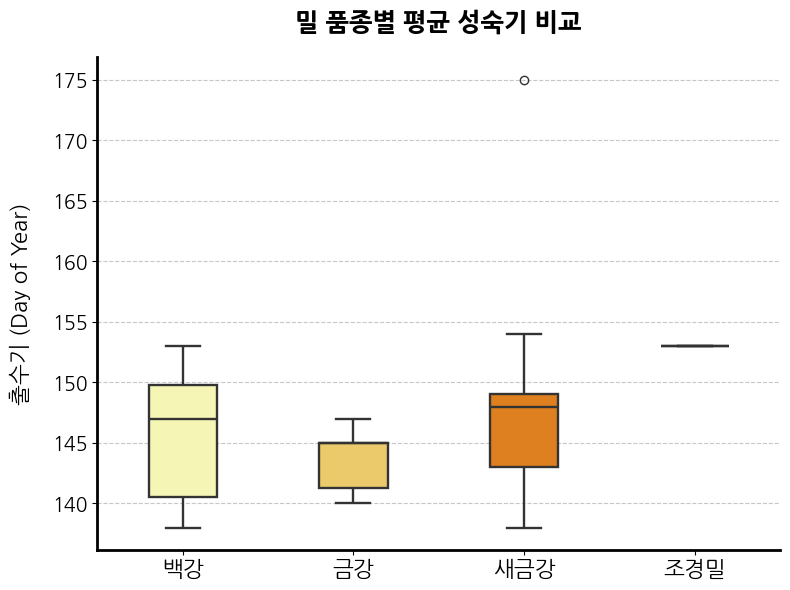

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

wheat_total['성숙기_DOY'] = wheat_total['성숙기'].dt.dayofyear
wheat_total = wheat_total[wheat_total['품종'].isin(['백강', '금강', '새금강', '조경밀'])]
wheat_varieties_order = ['백강', '금강', '새금강', '조경밀']

fig, ax = plt.subplots(figsize=(8, 6))
custom_palette = sns.color_palette("afmhot_r", n_colors=5)

# 박스플롯 생성
boxplot = sns.boxplot(
    data=wheat_total,
    x='품종',
    y='성숙기_DOY',
    ax=ax,
    width=0.4,
    palette=custom_palette,
    linewidth=1.7,
    order=wheat_varieties_order
)

# 제목 및 축 라벨 설정
ax.set_title('밀 품종별 평균 성숙기 비교', fontsize=18, pad=20, fontweight='bold', color='black')
ax.set_xlabel('')
ax.set_ylabel('출수기 (Day of Year)', fontsize=16, labelpad=15, color='black')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_linewidth(2.0)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['bottom'].set_color('black')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=16, colors='black')
ax.tick_params(axis='y', labelsize=14, colors='black')
plt.tight_layout()
plt.show()

#### 밀 품종별 생산량 비교

<ipython-input-13-660183db8480>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(
<ipython-input-13-660183db8480>:7: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  boxplot = sns.boxplot(


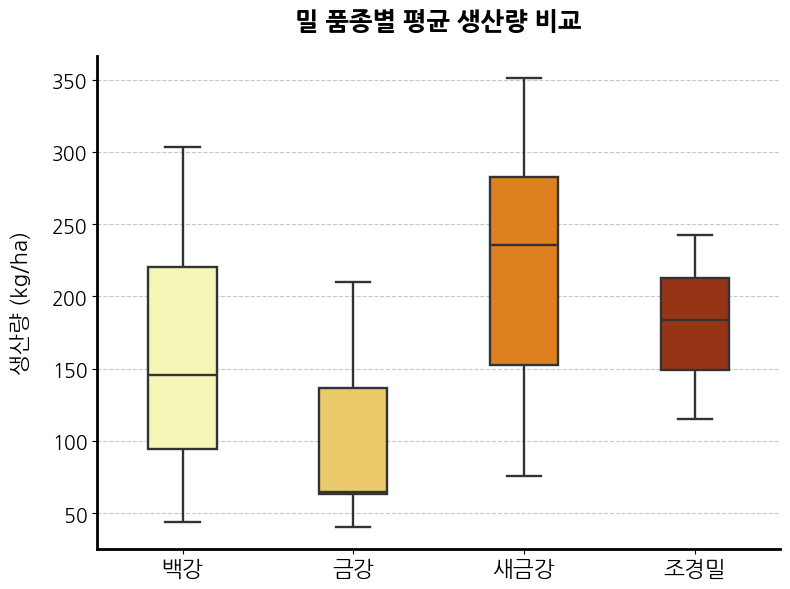

In [ ]:
wheat_info = wheat_info[wheat_info['품종'].isin(['백강', '금강', '새금강', '조경밀'])]

fig, ax = plt.subplots(figsize=(8, 6))
custom_palette = sns.color_palette("afmhot_r", n_colors=5)

# 박스플롯 생성
boxplot = sns.boxplot(
    data=wheat_info,
    x='품종',
    y='생산량_kg_ha',
    ax=ax,
    width=0.4,
    palette=custom_palette,
    linewidth=1.7
)

# 제목 및 축 라벨 설정
ax.set_title('밀 품종별 평균 생산량 비교', fontsize=18, pad=20, fontweight='bold', color='black')
ax.set_xlabel('')
ax.set_ylabel('생산량 (kg/ha)', fontsize=16, labelpad=15, color='black')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_linewidth(2.0)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['bottom'].set_color('black')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=16, colors='black')
ax.tick_params(axis='y', labelsize=14, colors='black')
plt.tight_layout()
plt.show()

#### 밀 조사구역별 생육 추이

In [ ]:
crop_data['밀']['시군구'].unique()

In [ ]:
def draw_farm(farm_id):
  wheat_growth = crop_data['밀'][(crop_data['밀']['농가명'] == farm_id)]
  site = wheat_growth['시군구'].unique()[0]
  # wheat_growth = crop_data['밀'][(crop_data['밀']['시군구'] == site) & (crop_data['밀']['농가명'] == 2)]
  # print(wheat_growth.columns)

  fig, ax = plt.subplots(figsize=(10, 6))
  markers = {'R1': 'o', 'R2': 's', 'R3': '^'}
  palette = {'R1': '#0072B2', 'R2': '#D55E00', 'R3': '#009E73'}

  # 각 조사구역별로 산점도
  for region in wheat_growth['조사구역'].unique()[:3]:
      # print(wheat_growth['조사구역'].unique())
      region_data = wheat_growth[wheat_growth['조사구역'] == region]
      ax.scatter(
          region_data['조사일'],
          region_data['초장'],
          s=100,
          alpha=0.8,
          color=palette[region],
          marker=markers[region],
          label=region,
          edgecolor='black',
          linewidth=0.5
      )

  date_format = DateFormatter('%Y-%m-%d')
  ax.xaxis.set_major_formatter(date_format)
  fig.autofmt_xdate(rotation=45)  # 날짜 레이블 회전

  for spine in ['top', 'right']:
      ax.spines[spine].set_visible(False)
  for spine in ['left', 'bottom']:
      ax.spines[spine].set_linewidth(1.2)
      ax.spines[spine].set_color('black')

  ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5)
  ax.grid(axis='x', visible=False)

  plt.title(f'{site} 밀 초장 성장 변화 (농가명: {wheat_growth["농가명"].unique()[0]})', fontsize=14, fontweight='bold', pad=15)
  plt.xlabel('')
  plt.ylabel('초장 (cm)', fontsize=12, fontweight='bold', labelpad=10)

  ax.tick_params(axis='x', labelsize=10, colors='black', direction='out', length=4)
  ax.tick_params(axis='y', labelsize=10, colors='black', direction='out', length=4)

  legend = ax.legend(
      title='조사구역',
      title_fontsize=11,
      fontsize=10,
      frameon=True,
      loc='upper left',
      bbox_to_anchor=(1.02, 1),
      edgecolor='gray',
      framealpha=0.95
  )
  legend.get_frame().set_linewidth(0.8)

  y_min, y_max = ax.get_ylim()
  ax.set_ylim(y_min - 2, y_max + 2)

  plt.tight_layout()
  plt.show()

In [ ]:
crop_data['밀']['농가명'].unique()

In [ ]:
from matplotlib.dates import DateFormatter

draw_farm(2)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

sorted_data = wheat_info.sort_values('생산량_kg_ha', ascending=False)
colors = sns.color_palette("copper", len(sorted_data['시군'].unique()))

# 향상된 바 차트 생성
bars = sns.barplot(
    data=sorted_data,
    x='시군',
    y='생산량_kg_ha',
    palette=colors,
    ax=ax
)

for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# 그래프 타이틀 및 레이블 설정
ax.set_title('시군별 밀 생산량 비교', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('')
ax.set_ylabel('생산량 (kg/ha)', fontsize=14, labelpad=10)

ax.tick_params(axis='x', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelsize=14)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 그래프 테두리 추가
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#DDDDDD')

plt.show()

### 고랭지 배추 시각화

In [ ]:
farm_info_w_cabbage = farm_info[farm_info['작목'] == '고랭지배추'].copy()
farm_info_w_cabbage['연도'] = farm_info_w_cabbage['연도'].astype(int)

crop_data_w_cabbage = crop_data['고랭지배추'].copy()
crop_data_w_cabbage['연도'] = crop_data_w_cabbage['연도'].astype(int)

w_cabbage_total = pd.merge(
    farm_info_w_cabbage,
    crop_data_w_cabbage,
    left_on=['연도', '지역(도)', '시군', '농가명'],
    right_on=['연도', '시도', '시군구', '농가명'],
    how='outer'
)

w_cabbage_total = w_cabbage_total.dropna(subset=['농가명'])
w_cabbage_total

In [ ]:
print('고랭지배추 자료 시군 목록: ', crop_data['고랭지배추']['시군구'].unique())
print('고랭지배추 자료 시군 목록: ', w_cabbage_total['시군구'].unique())
print('고랭지배추 자료 품종 목록: ', farm_info[farm_info['작목'] == '고랭지배추']['품종'].unique())
print('고랭지배추 자료 연도 목록: ', farm_info[farm_info['작목'] == '고랭지배추']['연도'].unique())
print('고랭지배추 자료 농가 목록: ', farm_info[farm_info['작목'] == '고랭지배추']['농가명'].unique())

In [ ]:
w_cabbage_info = farm_info[farm_info['작목'] == '고랭지배추']
w_cabbage_info['생산량_kg_ha'] = w_cabbage_info['총수확량'] / (w_cabbage_info['포장면적'] / 1000)
display(w_cabbage_info[['품종', '생산량_kg_ha']].head(10))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# w_cabbage_total['성숙기_DOY'] = w_cabbage_total['성숙기'].dt.dayofyear
w_cabbage_info = w_cabbage_info[w_cabbage_info['품종'].isin(['춘광', '수호', '청옥', '오대',  '썸머타임',  '청광', '썸머탑' '썸머스타','청복'])]
# w_cabbage_varieties_order = ['백강', '금강', '새금강', '조경밀']

fig, ax = plt.subplots(figsize=(8, 6))
custom_palette = sns.color_palette("summer", n_colors=5)

# 박스플롯 생성
boxplot = sns.boxplot(
    data=w_cabbage_info,
    x='품종',
    y='생산량_kg_ha',
    ax=ax,
    width=0.5,
    palette=custom_palette,
    linewidth=1.7,
)

# 제목 및 축 라벨 설정
ax.set_title('고랭지배추 품종별 평균 생산량 비교', fontsize=18, pad=20, fontweight='bold', color='black')
ax.set_xlabel('')
ax.set_ylabel('생산량 ($kg/ha$)', fontsize=16, labelpad=15, color='black')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_linewidth(2.0)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['bottom'].set_color('black')

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.tick_params(axis='x', labelsize=16, colors='black')
ax.tick_params(axis='y', labelsize=14, colors='black')
plt.tight_layout()
plt.show()

### 고랭지 배추 분석하기(기상결합)


In [ ]:
env_2019 = pd.read_csv('./asos_weather/105_2019.csv')
env_2020 = pd.read_csv('./asos_weather/105_2020.csv')
env_2021 = pd.read_csv('./asos_weather/105_2021.csv')
env_2022 = pd.read_csv('./asos_weather/105_2022.csv')
env_data = pd.concat([env_2019, env_2020, env_2021, env_2022], ignore_index=True)

env_data['date_str'] = env_data['year'].astype(str) + '-' + env_data['day'].astype(str).str.zfill(3)
env_data['DateTime'] = pd.to_datetime(env_data['date_str'], format='%Y-%j')
env_data = env_data.drop('date_str', axis=1)
env_data.info()

In [ ]:
# w_cabbage_info[['연도', '시군', '농가명','정식일자', '수확일자']]

# GDD 계산 함수 정의 (기준온도: 0°C로 가정, 필요에 따라 조정)
def calculate_gdd(tmax, tmin, base_temp=0):
    tavg = (tmax + tmin) / 2
    gdd = max(0, tavg - base_temp)
    return gdd

env_data['GDD'] = env_data.apply(lambda row: calculate_gdd(row['maxTa'], row['minTa']), axis=1)

daily_gdd_results = []
# 각 농가별로 정식일자부터 수확일자까지의 일별 GDD 계산 및 적산
for idx, row in w_cabbage_info.iterrows():
    year = row['연도']
    region = row['시군']
    farmer = row['농가명']
    plant_date = row['정식일자']
    harvest_date = row['수확일자']

    # 해당 기간의 env_data 필터링
    period_data = env_data[(env_data['DateTime'] >= plant_date) &
                          (env_data['DateTime'] <= harvest_date)].copy()

    if len(period_data) > 0:
        # 정식 시작일부터의 누적 일수 계산
        period_data['생육일수'] = (period_data['DateTime'] - plant_date).dt.days + 1

        # 일별 GDD 적산값 계산 (누적합)
        period_data['총GDD'] = period_data['GDD'].cumsum()

        for _, day_data in period_data.iterrows():
            daily_gdd_results.append({
                '연도': year,
                '시군': region,
                '농가명': farmer,
                '정식일자': plant_date,
                '수확일자': harvest_date,
                '날짜': day_data['DateTime'],
                '생육일수': day_data['생육일수'],
                '일GDD': day_data['GDD'],
                '총GDD': day_data['총GDD']
            })

daily_gdd_results_df = pd.DataFrame(daily_gdd_results)
daily_gdd_results_df

In [ ]:
crop_data['고랭지배추']['연도'] = crop_data['고랭지배추']['연도'].astype(str)
daily_gdd_results_df['연도'] = daily_gdd_results_df['연도'].astype(str)

w_cabbage_growth_total = pd.merge(crop_data['고랭지배추'], daily_gdd_results_df, left_on=['연도', '시군구', '농가명', '조사일'], right_on=['연도', '시군', '농가명', '날짜'],how='left')
w_cabbage_growth_total

In [ ]:
from matplotlib.dates import DateFormatter

# 필터링
site = '강릉시'
w_cabbage_growth = crop_data['고랭지배추'][(crop_data['고랭지배추']['시군구'] == site) & (crop_data['고랭지배추']['농가명'] == 3) & (crop_data['고랭지배추']['연도'] == '2022')]

fig, ax = plt.subplots(figsize=(10, 6))
markers = {'R1': 'o', 'R2': 's', 'R3': '^'}
palette = {'R1': '#0072B2', 'R2': '#D55E00', 'R3': '#009E73'}

# 각 조사구역별로 산점도
for region in w_cabbage_growth['조사구역'].unique():
    region_data = w_cabbage_growth[w_cabbage_growth['조사구역'] == region]
    ax.scatter(
        region_data['조사일'],
        region_data['엽수'],
        s=100,
        alpha=0.8,
        color=palette[region],
        marker=markers[region],
        label=region,
        edgecolor='black',
        linewidth=0.5
    )

date_format = DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)
fig.autofmt_xdate(rotation=45)  # 날짜 레이블 회전

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_color('black')

ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='x', visible=False)

plt.title(f'{site} 고랭지배추 엽수 변화', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('엽수', fontsize=12, fontweight='bold', labelpad=10)

ax.tick_params(axis='x', labelsize=10, colors='black', direction='out', length=4)
ax.tick_params(axis='y', labelsize=10, colors='black', direction='out', length=4)

legend = ax.legend(
    title='조사구역',
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    edgecolor='gray',
    framealpha=0.95
)
legend.get_frame().set_linewidth(0.8)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - 2, y_max + 2)

plt.tight_layout()
plt.show()

### 엽수 예측모델

In [ ]:
from scipy.stats import linregress

# 데이터 전처리: '총GDD'와 '엽수' 컬럼의 결측치를 제거함
df_clean = w_cabbage_growth_total[['총GDD', '엽수']].dropna()

x = df_clean['총GDD']
y = df_clean['엽수']

# 선형 회귀분석 수행: 회귀계수, 절편, 상관계수 및 결정계수(R^2) 산출
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value ** 2

# Figure 생성: 검정색 산점도와 빨간색 회귀 추세선을 포함함 (dpi 옵션 미사용)
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df_clean, x='총GDD', y='엽수', ax=ax,
            scatter_kws={'color': 'black', 's':20, 'alpha': 0.3, 'linewidths': 0}, line_kws={'color': 'red'})

# 회귀방정식과 결정계수(R^2)를 Figure 내부에 표기
equation_text = f"$y = {slope:.2f}x + {intercept:.2f}$\n$R^2 = {r_squared:.2f}$"
ax.text(0.05, 0.95, equation_text, transform=ax.transAxes,
        fontsize=14, verticalalignment='top')

# 축 라벨 및 제목 설정 (논문 스타일)
ax.set_xlabel('총 누적 GDD', fontsize=12)
ax.set_ylabel('엽수 (개)', fontsize=12)
ax.set_title('총 누적 GDD와 엽수 간의 선형 관계', fontsize=14)

plt.grid(False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_color('black')

ax.tick_params(axis='x', labelsize=10, colors='black', direction='out', length=4)
ax.tick_params(axis='y', labelsize=10, colors='black', direction='out', length=4)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import r2_score

# 2차 회귀 모델 생성
model = np.poly1d(np.polyfit(df_clean['총GDD'], df_clean['엽수'], 2))
r_squared = r2_score(df_clean['엽수'], model(df_clean['총GDD']))

# Figure 생성: 검정색 산점도와 빨간색 회귀 추세선을 포함함 (dpi 옵션 미사용)
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df_clean, x='총GDD', y='엽수', ax=ax,
            scatter_kws={'color': 'black', 's':20, 'alpha': 0.3, 'linewidths': 0}, line_kws={'color': 'red'}, order=2)

# 회귀방정식과 결정계수(R^2)를 Figure 내부에 표기
# 회귀방정식 문자열 생성
equation_text = f"$y = {model[2]:.3e}x^2 + {model[1]:.3e}x + {model[0]:.2f}$"
equation_text += f"\n$R^2 = {r_squared:.2f}$"
ax.text(0.05, 0.95, equation_text, transform=ax.transAxes,
        fontsize=14, verticalalignment='top')

# 축 라벨 및 제목 설정 (논문 스타일)
ax.set_xlabel('총 누적 GDD', fontsize=12)
ax.set_ylabel('엽수 (개)', fontsize=12)
ax.set_title('총 누적 GDD와 엽수 간의 2차 회귀 관계', fontsize=14)

plt.grid(False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.2)
    ax.spines[spine].set_color('black')

ax.tick_params(axis='x', labelsize=10, colors='black', direction='out', length=4)
ax.tick_params(axis='y', labelsize=10, colors='black', direction='out', length=4)

plt.tight_layout()
plt.show()